In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ealaxi/paysim1")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/ealaxi/paysim1


In [2]:
!pip install xgboost imbalanced-learn joblib -q

In [3]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc
)

from sklearn.ensemble import IsolationForest

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [4]:
DATA_PATH = "/kaggle/input/datasets/ealaxi/paysim1/PS_20174392719_1491204439457_log.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [6]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [7]:
fraud_percent = (df["isFraud"].sum() / len(df)) * 100

print(f"Fraud Percentage: {fraud_percent:.4f}%")

Fraud Percentage: 0.1291%


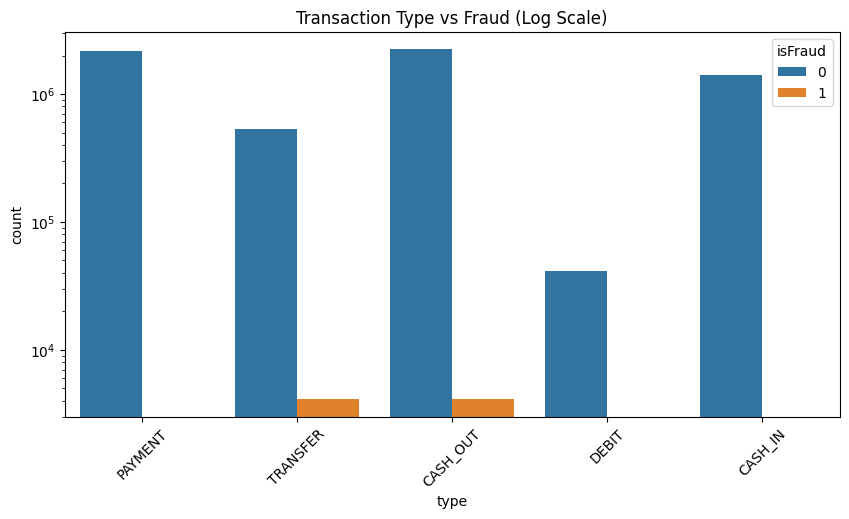

In [8]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    x="type",
    hue="isFraud",
    data=df
)

plt.yscale("log")

plt.title("Transaction Type vs Fraud (Log Scale)")
plt.xticks(rotation=45)

plt.show()

In [9]:
fraud_by_type = pd.crosstab(
    df["type"],
    df["isFraud"],
    normalize="index"
) * 100

fraud_by_type

isFraud,0,1
type,,
CASH_IN,100.000000,0.000000
CASH_OUT,99.816045,0.183955
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000
TRANSFER,99.231201,0.768799


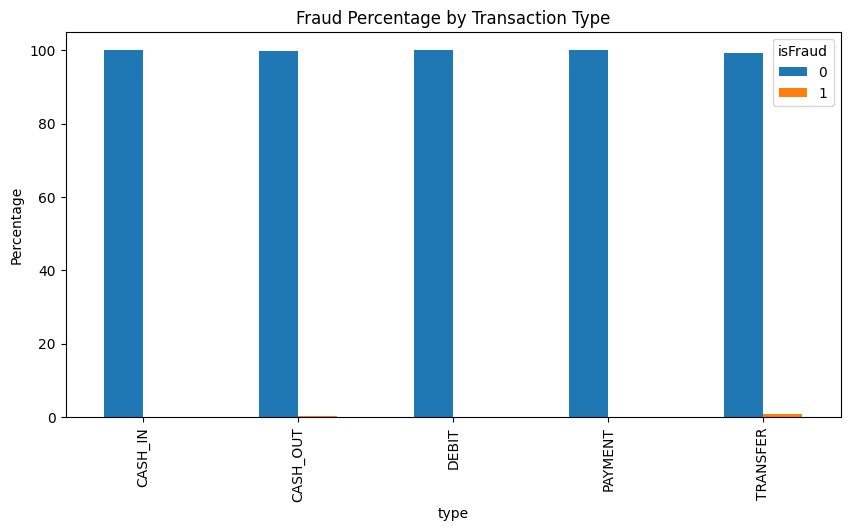

In [10]:
fraud_by_type.plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylabel("Percentage")
plt.title("Fraud Percentage by Transaction Type")

plt.show()

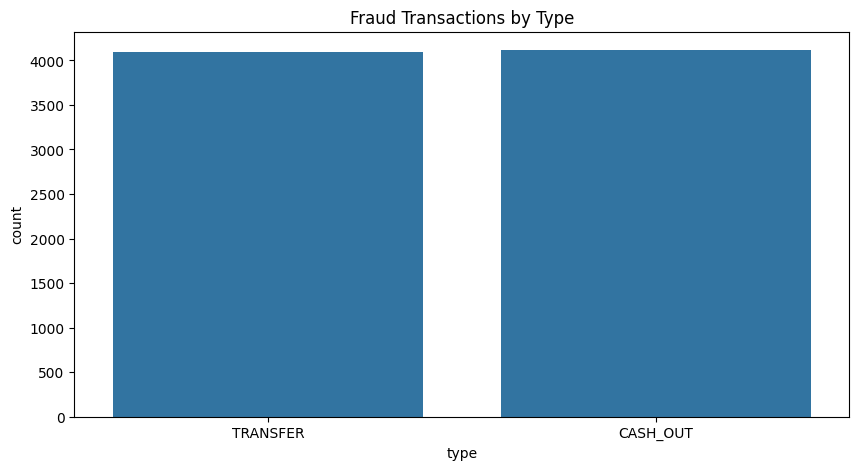

In [11]:
plt.figure(figsize=(10,5))

fraud_only = df[df["isFraud"] == 1]

sns.countplot(
    x="type",
    data=fraud_only
)

plt.title("Fraud Transactions by Type")

plt.show()

In [12]:
df["orig_balance_error"] = (
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"]
)

df["dest_balance_error"] = (
    df["oldbalanceDest"]
    + df["amount"]
    - df["newbalanceDest"]
)

df[[
    "orig_balance_error",
    "dest_balance_error"
]].head()

,orig_balance_error,dest_balance_error
0,0.0,9839.64
1,0.0,1864.28
2,0.0,181.00
3,0.0,21363.00
4,0.0,11668.14


In [13]:
df["nameOrig_txn_count"] = (
    df.groupby("nameOrig")["step"]
    .transform("count")
)

In [14]:
df["nameDest_txn_count"] = (
    df.groupby("nameDest")["step"]
    .transform("count")
)

In [15]:
df["nameOrig_mean_amount"] = (
    df.groupby("nameOrig")["amount"]
    .transform("mean")
)

In [16]:
df["nameDest_mean_amount"] = (
    df.groupby("nameDest")["amount"]
    .transform("mean")
)

In [17]:
df["hour"] = df["step"] % 24

df["hour"].head()

0    1
1    1
2    1
3    1
4    1
Name: hour, dtype: int64

In [18]:
large_threshold = df["amount"].quantile(0.99)

print(large_threshold)

1615979.4715999917


In [19]:
df["is_large_transaction"] = (
    df["amount"] > large_threshold
).astype(int)

In [20]:
df["orig_zero_balance"] = (
    df["newbalanceOrig"] == 0
).astype(int)

df["dest_zero_balance"] = (
    df["newbalanceDest"] == 0
).astype(int)

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["type"] = le.fit_transform(df["type"])

df["type"].head()

0    3
1    3
2    4
3    1
4    3
Name: type, dtype: int64

In [22]:
drop_cols = [
    "nameOrig",
    "nameDest",
    "isFlaggedFraud"
]

df = df.drop(columns=drop_cols)

df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,orig_balance_error,dest_balance_error,nameOrig_txn_count,nameDest_txn_count,nameOrig_mean_amount,nameDest_mean_amount,hour,is_large_transaction,orig_zero_balance,dest_zero_balance
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0,0.0,9839.64,1,1,9839.64,9839.640000,1,0,0,1
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0,0.0,1864.28,1,1,1864.28,1864.280000,1,0,0,1
2,1,4,181.00,181.0,0.00,0.0,0.0,1,0.0,181.00,1,44,181.00,225517.832045,1,0,1,1
3,1,1,181.00,181.0,0.00,21182.0,0.0,1,0.0,21363.00,1,41,181.00,439444.208049,1,0,1,1
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0,0.0,11668.14,1,1,11668.14,11668.140000,1,0,0,1


In [23]:
df.columns

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud', 'orig_balance_error',
       'dest_balance_error', 'nameOrig_txn_count', 'nameDest_txn_count',
       'nameOrig_mean_amount', 'nameDest_mean_amount', 'hour',
       'is_large_transaction', 'orig_zero_balance', 'dest_zero_balance'],
      dtype='object')

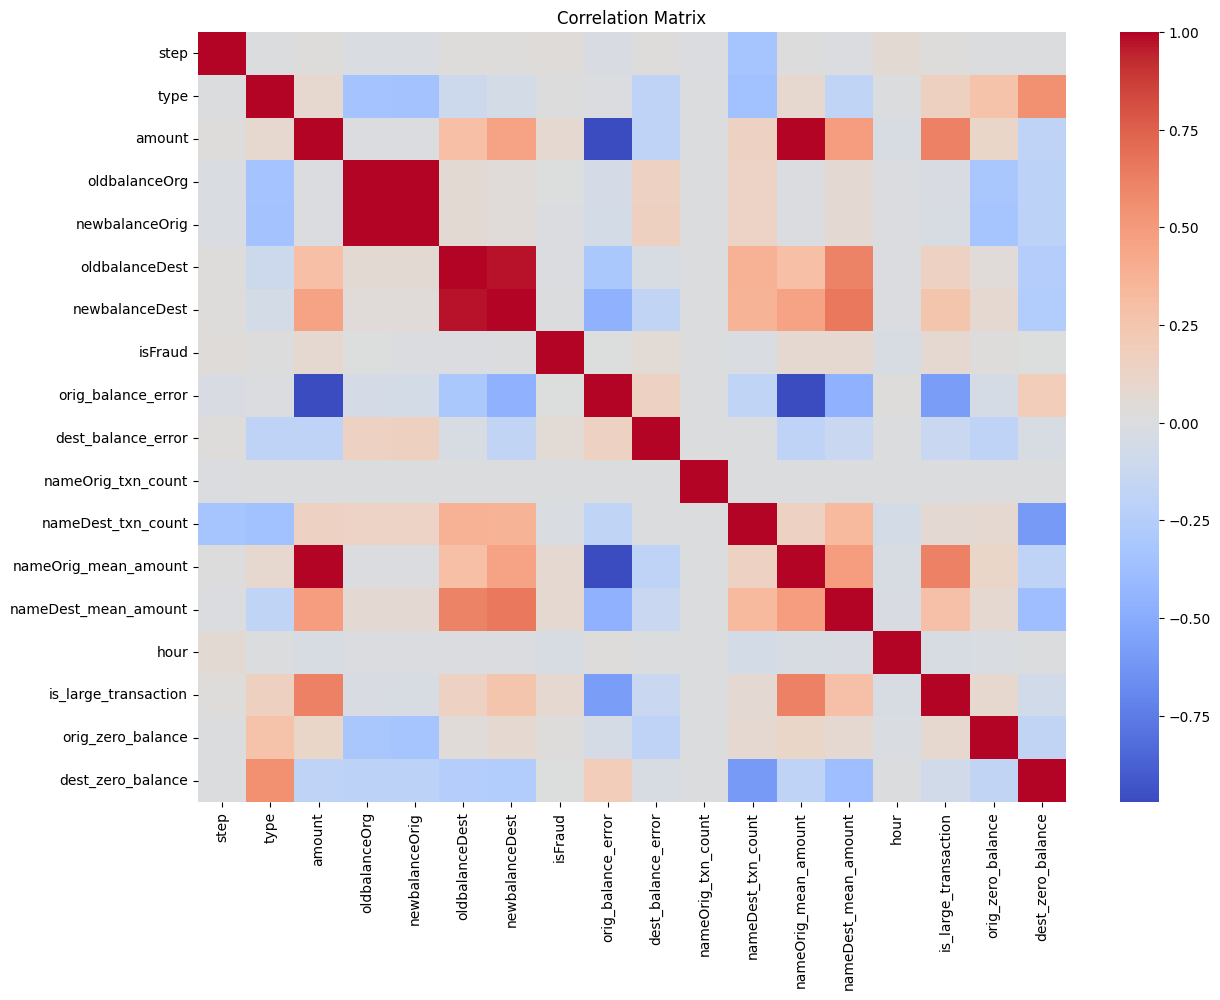

In [24]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()